In [1]:
# Step 1: Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded!")
print(f"Pandas version: {pd.__version__}")

✅ Libraries loaded!
Pandas version: 3.0.1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset load karo
df = pd.read_csv('../data/raw/dataset_diabetes/diabetic_data.csv')

print(f"✅ Dataset loaded!")
print(f"Total Patients: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"\nColumn Names:")
print(df.columns.tolist())

✅ Dataset loaded!
Total Patients: 101,766
Total Features: 50

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [4]:
# View first 5 rows of the dataset
print("=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== DATA TYPES ===")
print(df.dtypes.value_counts())

print("\n=== TARGET COLUMN DISTRIBUTION ===")
print(df['readmitted'].value_counts())

print("\nTarget Values:")
print("NO   = Patient was NOT readmitted")
print(">30  = Patient readmitted AFTER 30 days")
print("<30  = Patient readmitted WITHIN 30 days (HIGH RISK!)")

=== FIRST 5 ROWS ===


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



=== DATA TYPES ===
str      37
int64    13
Name: count, dtype: int64

=== TARGET COLUMN DISTRIBUTION ===
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Target Values:
NO   = Patient was NOT readmitted
>30  = Patient readmitted AFTER 30 days
<30  = Patient readmitted WITHIN 30 days (HIGH RISK!)


=== MISSING VALUES (marked as '?') ===
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64

Percentage of missing values:
race                  2.23
weight               96.86
payer_code           39.56
medical_specialty    49.08
diag_1                0.02
diag_2                0.35
diag_3                1.40
dtype: float64

=== TARGET: READMISSION DISTRIBUTION ===
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Total records: 101,766


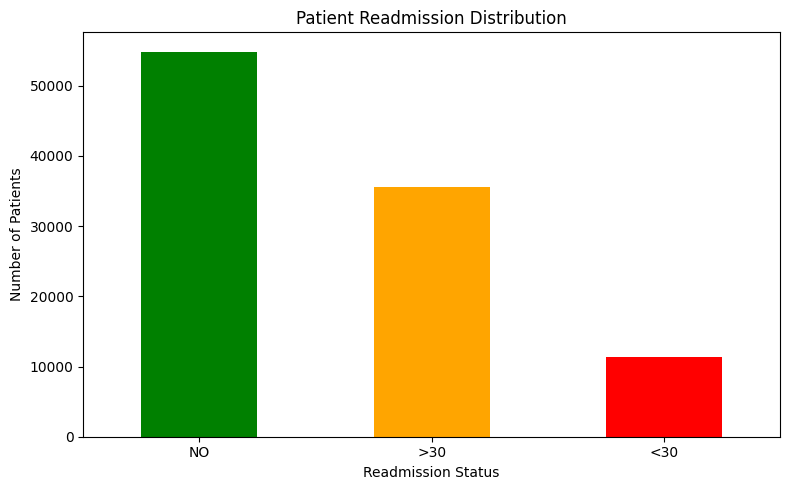

Chart saved!


In [5]:
# Check missing values (? marks in this dataset)
print("=== MISSING VALUES (marked as '?') ===")
missing = (df == '?').sum()
missing = missing[missing > 0]
print(missing)
print(f"\nPercentage of missing values:")
print((missing / len(df) * 100).round(2))

# Target column distribution
print("\n=== TARGET: READMISSION DISTRIBUTION ===")
print(df['readmitted'].value_counts())
print(f"\nTotal records: {len(df):,}")

# Visualize target
plt.figure(figsize=(8,5))
df['readmitted'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('Patient Readmission Distribution')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/cleaned/readmission_distribution.png')
plt.show()
print("Chart saved!")

In [6]:
# ============================================
# PHASE 3: DATA CLEANING
# ============================================

# Step 1: Replace all '?' with NaN
df.replace('?', np.nan, inplace=True)
print("✅ Replaced '?' with NaN")

# Step 2: Drop columns with too many missing values
cols_to_drop = ['weight', 'payer_code', 'medical_specialty']
df.drop(columns=cols_to_drop, inplace=True)
print(f"✅ Dropped high-missing columns: {cols_to_drop}")

# Step 3: Drop irrelevant ID columns
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)
print("✅ Dropped ID columns")

# Step 4: Convert target to binary
# 1 = readmitted within 30 days (HIGH RISK), 0 = otherwise
df['readmitted'] = (df['readmitted'] == '<30').astype(int)
print(f"\n✅ Target converted to binary:")
print(df['readmitted'].value_counts())
print(f"\nFinal dataset shape: {df.shape}")

✅ Replaced '?' with NaN
✅ Dropped high-missing columns: ['weight', 'payer_code', 'medical_specialty']
✅ Dropped ID columns

✅ Target converted to binary:
readmitted
0    90409
1    11357
Name: count, dtype: int64

Final dataset shape: (101766, 45)


In [7]:
# ============================================
# PHASE 3 CONTINUED: ENCODE + SAVE
# ============================================

# Step 1: Convert categorical columns to numbers
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {len(categorical_cols)}")
print(categorical_cols)

# Label encoding for all categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col].astype(str))

print("\n✅ All categorical columns encoded!")

# Step 2: Save cleaned dataset
df.to_csv('../data/cleaned/diabetic_cleaned.csv', index=False)
print("✅ Cleaned dataset saved to data/cleaned/diabetic_cleaned.csv")
print(f"Final shape: {df.shape}")
print(f"\nSample of cleaned data:")
display(df.head(3))

C:\Users\user\AppData\Local\Temp\ipykernel_5500\2813389162.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


Categorical columns to encode: 33
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

✅ All categorical columns encoded!
✅ Cleaned dataset saved to data/cleaned/diabetic_cleaned.csv
Final shape: (101766, 45)

Sample of cleaned data:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2,0,0,6,25,1,1,41,0,1,...,0,1,1,0,0,0,0,1,0,0
1,2,0,1,1,1,7,3,59,0,18,...,0,3,1,0,0,0,0,0,1,0
2,0,0,2,1,1,7,2,11,5,13,...,0,1,1,0,0,0,0,1,1,0


In [8]:
# ============================================
# PHASE 4: MACHINE LEARNING MODEL
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import pickle

# Step 1: Separate features and target
X = df.drop('readmitted', axis=1)
y = df['readmitted']
print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# Step 2: Split data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Train size: {X_train.shape[0]:,}")
print(f"✅ Test size: {X_test.shape[0]:,}")

# Step 3: Train XGBoost model
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=8,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)
print("\n✅ Model trained!")

# Step 4: Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print("\n=== MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Step 5: Save model
pickle.dump(model, open('../models/readmission_model.pkl', 'wb'))
print("\n✅ Model saved to models/readmission_model.pkl")

Features shape: (101766, 44)
Target distribution:
readmitted
0    90409
1    11357
Name: count, dtype: int64

✅ Train size: 81,412
✅ Test size: 20,354

✅ Model trained!

=== MODEL PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.93      0.67      0.78     18083
           1       0.18      0.58      0.28      2271

    accuracy                           0.66     20354
   macro avg       0.56      0.63      0.53     20354
weighted avg       0.84      0.66      0.72     20354

ROC-AUC Score: 0.6831

✅ Model saved to models/readmission_model.pkl
